Tugas:
Perbandingan Filter Median vs Filter Rata-rata untuk noise salt-and-pepper.

Tahapan:
1. Tambahkan noise salt-and-pepper ke citra grayscale.
2. Terapkan filter rata-rata (mean filter dengan kernel konvolusi).
3. Terapkan filter median.
4. Bandingkan hasil visual serta nilai error terhadap citra asli.

Fokus analisis:
- Seberapa baik noise impuls dihilangkan.
- Dampak pada ketajaman tepi objek.

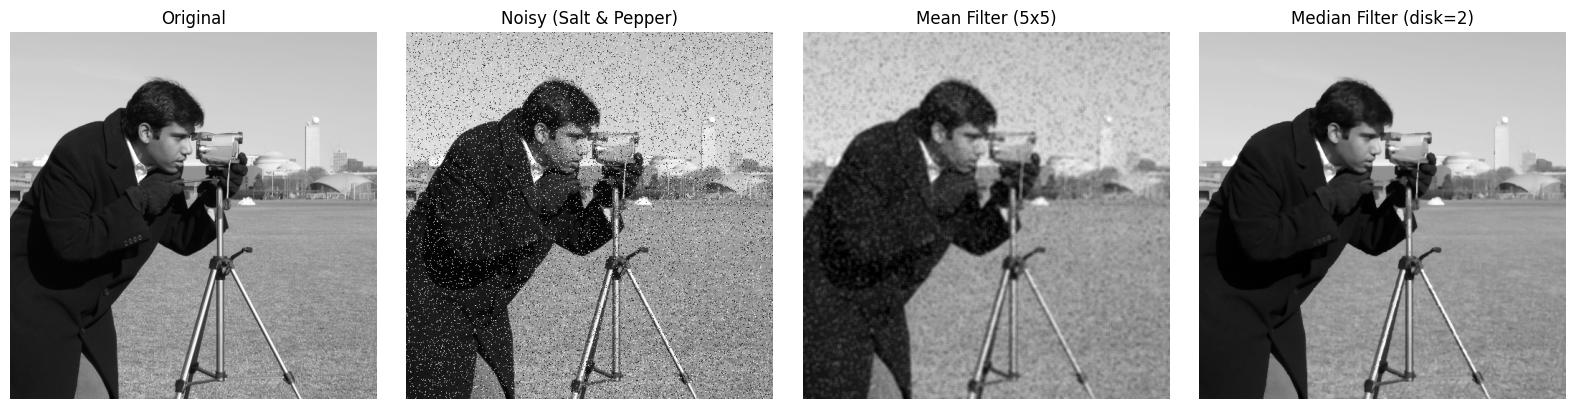

Perbandingan MSE terhadap citra asli:
- Mean filter   : 0.003837
- Median filter : 0.001137
Perbandingan PSNR terhadap citra asli:
- Mean filter   : 24.16 dB
- Median filter : 29.44 dB
Kesimpulan: Median filter lebih unggul untuk noise impuls (salt-and-pepper).


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage as ndi
from skimage import data, util, filters, morphology, img_as_float
from skimage.metrics import peak_signal_noise_ratio

# 1) Citra grayscale asli
img = img_as_float(data.camera())

# 2) Tambahkan noise salt-and-pepper
img_noisy = util.random_noise(img, mode='s&p', amount=0.08)

# 3) Filter rata-rata (mean filter)
kernel_size = 5
kernel = np.ones((kernel_size, kernel_size), dtype=float) / (kernel_size * kernel_size)
img_mean = ndi.convolve(img_noisy, kernel, mode='reflect')

# 4) Filter median
img_median = filters.median(img_noisy, morphology.disk(2))

# 5) Hitung metrik error sederhana (MSE)
mse_mean = np.mean((img - img_mean) ** 2)
mse_median = np.mean((img - img_median) ** 2)
psnr_mean = peak_signal_noise_ratio(img, img_mean, data_range=1.0)
psnr_median = peak_signal_noise_ratio(img, img_median, data_range=1.0)

# 6) Tampilkan hasil
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(img, cmap='gray')
axes[0].set_title("Original")
axes[0].axis('off')

axes[1].imshow(img_noisy, cmap='gray')
axes[1].set_title("Noisy (Salt & Pepper)")
axes[1].axis('off')

axes[2].imshow(img_mean, cmap='gray')
axes[2].set_title(f"Mean Filter ({kernel_size}x{kernel_size})")
axes[2].axis('off')

axes[3].imshow(img_median, cmap='gray')
axes[3].set_title("Median Filter (disk=2)")
axes[3].axis('off')

plt.tight_layout()
plt.show()

print("Perbandingan MSE terhadap citra asli:")
print(f"- Mean filter   : {mse_mean:.6f}")
print(f"- Median filter : {mse_median:.6f}")
print("Perbandingan PSNR terhadap citra asli:")
print(f"- Mean filter   : {psnr_mean:.2f} dB")
print(f"- Median filter : {psnr_median:.2f} dB")

if mse_median < mse_mean:
    print("Kesimpulan: Median filter lebih unggul untuk noise impuls (salt-and-pepper).")
else:
    print("Kesimpulan: Pada konfigurasi ini mean filter lebih baik, namun secara umum median unggul untuk noise impuls.")